# Rosenblat's Perceptron

Before understanding Support Vector Machines, it is useful to first understand perceptrons. A perceptron is a linear classifier that uses a linear combination of input features to predict the sign of the output. The goal is to find a hyperplane that separates the data into two classes. If the data is linearly separable, the perceptron algorithm is guaranteed to converge. The hyperplane $L$ is defined by a vector normal to the surface and a shift from the origin. Changing the normal vector changes the orientation (i.e., rotates the hyperplane), while changing the shift moves the hyperplane parallel to itself.

A hyperplane is a surface $L$ in an $n$-dimensional feature space that separates the data. Consider any two points on this surface:
$$
x_1, x_2 \in L
$$
The vector connecting these two points,
$$
x_1 - x_2,
$$
lies entirely along the surface. Let $\beta$ be a vector perpendicular (normal) to this surface. This vector need not be a unit vector. Since $\beta$ is perpendicular to any vector lying on the surface:
$$
\beta \cdot (x_1 - x_2) = 0
$$
Expanding:
$$
\beta \cdot x_1 - \beta \cdot x_2 = 0
$$
which implies:
$$
\beta \cdot x_1 = \beta \cdot x_2
$$
Thus, the dot product of $\beta$ with any point on the surface is the same. Therefore, for every point $x \in L$:
$$
\beta \cdot x = c
$$
where $c$ is a constant. This is the fundamental equation of a hyperplane.

Let $z$ be the point on the hyperplane closest to the origin. At this point, $z$ is perpendicular to the surface and hence parallel to $\beta$. Therefore:
$$
\beta \cdot z = \|\beta\| \|z\| \cos(0) = \|\beta\| \|z\|
$$

Since for any other point $x$ on the plane, $\beta \cdot x = \|\beta\| \|z\|$, we have:
$$
c = \|\beta\| z
$$

Now,
$$
\beta \cdot x - c = 0
$$

Rewriting this:
$$
\beta \cdot x + \beta_0 = 0
$$
where:
$$
\beta_0 = -c = -\|\beta\| z
$$

Thus,
$$
\beta \cdot x + \beta_0 = 0
$$
defines the hyperplane $L$. Any point on one side will satisfy $\beta \cdot x + \beta_0 > 0$, while points on the other side will have $\beta \cdot x + \beta_0 < 0$.

With perceptron classifier, a point $x$ is classified using:
$$
\text{sign}(\beta \cdot x + \beta_0)
$$

A correct classification satisfies:
$$
y_i (\beta \cdot x_i + \beta_0) > 0
$$

The perceptron algorithm iteratively updates $\beta$ and $\beta_0$ whenever a point is misclassified, eventually finding a separating hyperplane if the data is linearly separable.




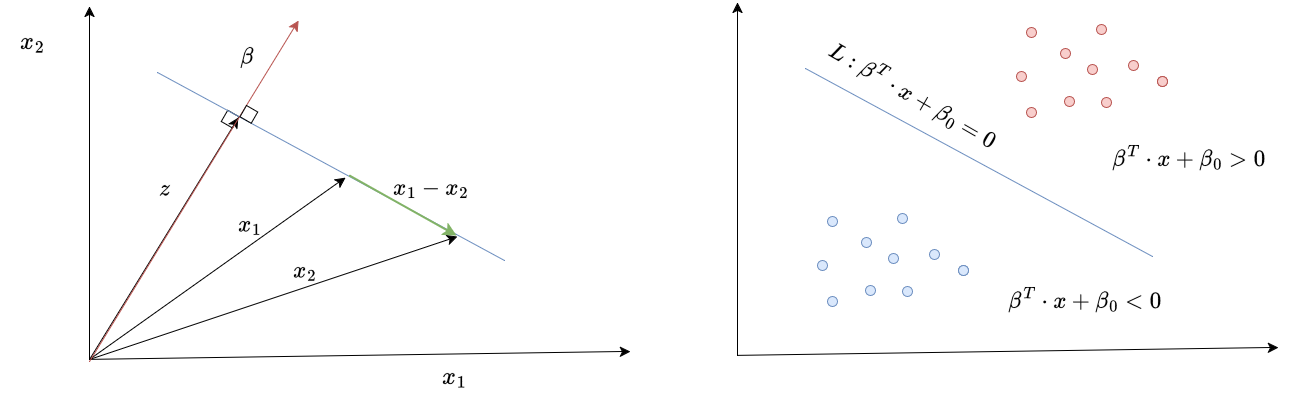

In [1]:
import numpy as np

In [81]:
class Perceptron:
    def __init__(self,max_iter=1000):
        self.max_iter = max_iter
        
    def fit(self, X, Y):
        n_samples, n_features = X.shape
        print(n_samples, n_features)
        # initialize parameters
        self.beta = np.zeros(n_features)
        self.beta0 = 0.0
        
        for iter in range(self.max_iter):
            
            m = 0 # count misclassified points
            
            for ij in range(n_samples):
                
                if Y[ij] * (np.dot(self.beta, X[ij]) + self.beta0) <= 0:

                    # Update step
                    self.beta += Y[ij] * X[ij]
                    self.beta0 += Y[ij]
                    m += 1
                    
            if m == 0:
                break

100 2
[ 76.5 -97.7] -120.0


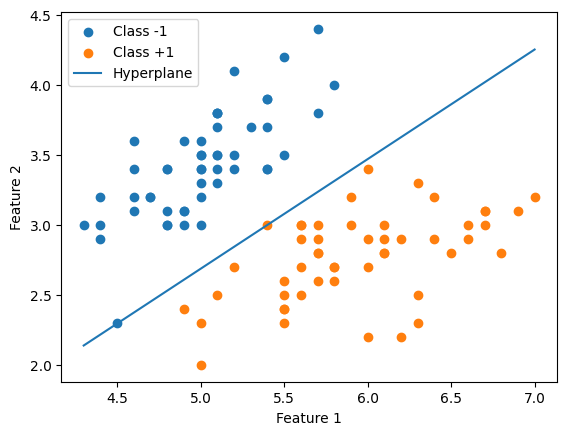

In [82]:
from sklearn import datasets
import matplotlib.pyplot as plt
iris = datasets.load_iris()

X = iris.data[:100,:2]
Y = iris.target[:100]

# Shuffle
idx = np.random.permutation(len(X))
X = X[idx]
Y = Y[idx]

for ij in range(len(Y)):
    if(Y[ij]==0):
        Y[ij] = -1

# Train model
model = Perceptron()
model.fit(X, Y)
print(model.beta,model.beta0)


# Plotting
plt.scatter(X[Y == -1][:, 0], X[Y == -1][:, 1], label="Class -1")
plt.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], label="Class +1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

x_vals = np.linspace(X[:,0].min(),X[:,0].max(),100)
# Line: beta1*x1 + beta2*x2 + beta0 = 0
# Solve for x2:
# x2 = -(beta1*x1 + beta0)/beta2
y_vals = -(model.beta[0] * x_vals + model.beta0) / model.beta[1]

plt.plot(x_vals,y_vals,label="Hyperplane")

# Compare Linear Regression results
plt.legend()
plt.show()